Для решения задачи в качестве вещественной переменной из дтасета из 1 промежуточной возьмем показатель средней температуры станка temp_avg. 

Целевая переменная Y: 
temp_avg (средняя температура станка - нетепичное повышение температура является показателем износа)

Объясняющие переменные (X): 
1. power_avg (потребляемая мощность — чем сильнее нагружен двигатель, тем выше нагрев).
2. rpm_avg (скорость вращения — физическое трение напрямую зависит от оборотов).
3. operation_count (интенсивность работы — количество операций за 6 часов).
4. age_days (возраст станка — старые станки из-за износа могут греться сильнее).


In [60]:
from sqlalchemy import create_engine, text
from dotenv import load_dotenv
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, root_mean_squared_error, r2_score

 

In [61]:
# загрузим данные, определим таргет и фичи

df = pd.read_csv("./v_machine_features_predictive.csv", parse_dates=['snapshot_time'])

target = 'temp_avg'
features = ['power_avg', 'rpm_avg', 'operation_count', 'age_days']

df_reg = df[[target] + features].dropna() # подготовим датафрейм и очистим от пропусков.


In [62]:
df_reg

,temp_avg,power_avg,rpm_avg,operation_count,age_days
4,65.900082,1.207881,2367.635832,1,1984
5,67.074685,1.251723,2432.010846,1,1984
6,67.074685,1.251723,2432.010846,1,1984
7,67.074685,1.251723,2432.010846,1,1984
8,67.074685,1.251723,2432.010846,1,1984
...,...,...,...,...,...
366548,67.353157,1.248136,2403.311057,1,3052
366549,67.353157,1.248136,2403.311057,1,3052
366550,67.353157,1.248136,2403.311057,1,3052
366551,68.894950,1.284586,2515.760677,0,3052


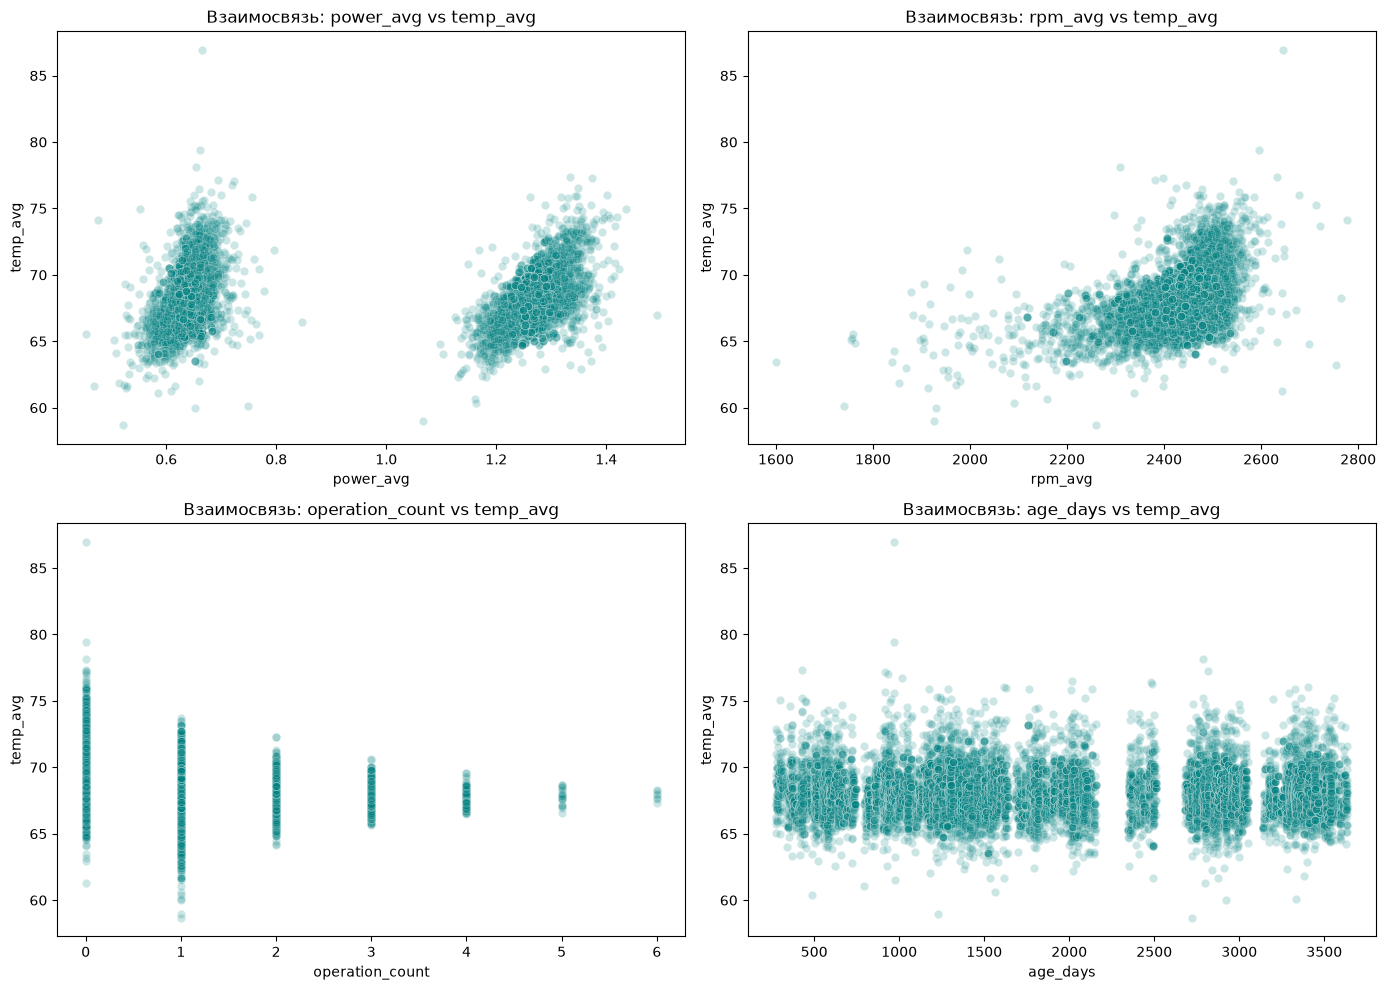

In [63]:
# построим тьочечечные диаграммы
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.scatterplot(x=df_reg[col], y=df_reg[target], alpha=0.2, color='teal', ax=axes[i])
    axes[i].set_title(f'Взаимосвязь: {col} vs {target}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel(target)

plt.tight_layout()
plt.show()


Проанализируем полученые графики.
1. Потребляемая мощность. power_avg vs temp_avg. На графике наблюдается двухкластерная прямая линейная зависимость. Данные разбились на 2 изолированные группы (первая в диапазоне 0.5 - 0.7, вторая 1.1 - 1.4). это указывает на то что есть 2 разные группы станков по мощности. Внутри каждой группы прослеживается линейная зависисмость (чем выше мощность, тем сильнее нагреваютеся узел станка)
2. Скорость вращения. rpm_avg vs temp_avg. На графике видно плотное облако точек с восходящим линейным трендом. Основная концентрация точек наблюдается в диапазоне от 2200 до 2600 оборотов. примерно с 2200 оборотов температура начинает рости с увеличением оборотов.
3. Интенсивность работы. operation_count vs temp_avg. На графике наблюдатеся максимальный разброс темературы на operation_count= 0 и 1. Возможно это может указывать на то, что станок может быть как горячим так и отсвшим после пересменки. по мере увеличения числа операций температура постепенно стабилизируется в райлне 68 градусов цельсия. Возрастающий тренд на графике отсутствует. Температура скорее стабилизируется с продолжительностью работы станков.
4. Возраст оборудования. age_days vs temp_avg. на графике не наблюдается выраженный тренд. станки разноговозраста имеют прирно однаковый диапахон температур. это говорит о том, что сам по себе возраст не влияет на рост температуры.

In [64]:
# Разделим датасет на обучающую и тестовую выборки
X = df_reg[features]
y = df_reg[target]

# ИСПРАВЛЕНО: аргумент test_test_split изменен на test_size
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Размер обучающей выборки: {X_train.shape[0]} строк")
print(f"Размер тестовой выборки: {X_test.shape[0]} строк")

Размер обучающей выборки: 9746 строк
Размер тестовой выборки: 2437 строк


In [65]:
# Обучим модель линейной регрессии на разных наборах переменных для разных спецификаций модели на обучающей выборке.and


# Спецификация 1: Простая парная регрессия (только базовый энергетический фактор)
model_1 = LinearRegression()
model_1.fit(X_train[['power_avg']], y_train)

# Спецификация 2: Множественная регрессия (только физические параметры режима работы)
model_2 = LinearRegression()
model_2.fit(X_train[['power_avg', 'rpm_avg']], y_train)

# Спецификация 3: Полная множественная регрессия (все доступные факторы)
model_3 = LinearRegression()
model_3.fit(X_train, y_train)



,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[ 0.08, 0.01,-0.41, 0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['power_avg','rpm_avg','operation_count','age_days']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,42.93
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


In [66]:
# Получаем прогнозы на отложенной тестовой выборке
pred_1 = model_1.predict(X_test[['power_avg']])
pred_2 = model_2.predict(X_test[['power_avg', 'rpm_avg']])
pred_3 = model_3.predict(X_test)

In [67]:
# Определяем функцию для  расчета метрик качества
def get_metrics(y_true, y_pred):
    mean_y = np.mean(y_true)
    std_y = np.std(y_true, axis = 0)
    mse = mean_squared_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {        'Mean_Y': mean_y,
        'Std_Y': std_y,
        'MAE': mae, 
        'MSE': mse,
        'RMSE': rmse, 
        'MAPE': mape,
        'R2': r2}

# Агрегируем результаты
all_results = {
    'Модель 1 (Только Power)': get_metrics(y_test, pred_1),
    'Модель 2 (Power + RPM)': get_metrics(y_test, pred_2),
    'Модель 3 (Все переменные)': get_metrics(y_test, pred_3)
}

# Выводим сводную таблицу метрик
df_metrics = pd.DataFrame(all_results).T
display(df_metrics)

,Mean_Y,Std_Y,MAE,MSE,RMSE,MAPE,R2
Модель 1 (Только Power),68.102407,1.858774,1.400785,3.425425,1.850790,0.020469,0.008571
Модель 2 (Power + RPM),68.102407,1.858774,1.265280,2.777829,1.666682,0.018478,0.196007
Модель 3 (Все переменные),68.102407,1.858774,1.256429,2.665123,1.632520,0.018368,0.228627


Выбираем спецификацию модели с наилучшим качеством.
на основе рассчетов раилучшее качество показывает 3я модель включаю щая в себя все перменные.
3 моедель имеет макмальный коэфециент детерминации R^2. имеет занчение 0.228627, что говорит о том, что эта модель объясняет 22.86% вариаций средней температуры.

Метрики  MAE, MSE и RMSE у модели 3 являются минимальными среди всех моделей.
метрика MAPE в 3й модели является минимальной, что указывает на то, что средняя ошибка модели составляет 1.8368%

Анализ качества модели:
Сопоставление со статистикой данных: Среднее значение температуры по выборке (Mean_Y) составляет 68.102407°C при естественном разбросе (Std_Y) в 1.858774°C. Величина финальной ошибки RMSE (1.632520°C) оказалась существенно ниже стандартного отклонения целевой переменной. Это математически доказывает, что обученная линейная регрессия обладает реальной предсказательной силой и работает намного лучше, чем тривиальное предсказание константным средним значением.
Практическая применимость: Ошибка MAPE на уровне 1.84% подтверждает высокую точность модели. 

In [68]:
# Выводим свободный член (коэффициент Intercept)
print(f"Свободный член (Intercept): {model_3.intercept_:.4f}\n")

print("Коэффициенты объясняющих переменных (моделирующие веса):")
# Сопоставляем названия фичей с их числовыми коэффициентами
for col, coef in zip(features, model_3.coef_):
    # Используем :.6f, так как для таких фичей как rpm_avg коэффициенты могут быть очень маленькими
    print(f"{col}: {coef:.6f}")

Свободный член (Intercept): 42.9267

Коэффициенты объясняющих переменных (моделирующие веса):
power_avg: 0.077273
rpm_avg: 0.010454
operation_count: -0.410975
age_days: 0.000000


$$ \text{temp\_avg} = 42.9267 + 0.077273 \cdot \text{power\_avg} + 0.010454 \cdot \text{rpm\_avg} - 0.410975 \cdot \text{operation\_count} + 0.000000 \cdot \text{age\_days} $$


Свободный член (Intercept = 42.9267): Отражает базовую температуру станка в условном состоянии покоя . Значение около 43°C  оправдано для промышленного цеха: это средняя температура остывающего оборудования после рабочей смены.

Потребляемая мощность (power_avg = +0.077273): Коэффициент имеет положительный знак. При увеличении средней потребляемой мощности станка на 1 единицу, его температура в среднем возрастает на 0.077°C (при неизменности остальных факторов). Часть электрической мощности рассеивается в виде тепла.

Скорость вращения (rpm_avg = +0.010454): Коэффициент положительный. Каждый дополнительный оборот в минуту увеличивает среднюю температуру станка на 0.010°C. Это дает весомый и самый статистически значимый вклад в нагрев за счет сил трения в механических узлах при высоких оборотах.

Количество операций (operation_count = -0.410975): Коэффициент  имеет отрицательный знак. Высокий operation_count (выпуск 4–6 деталей за 6 часов) характеризует стабильный, ритмичный и непрерывный режим работы конвейера, при котором эффективно работает штатная система охлаждения станка. Напротив, когда операций мало или они равны нулю, станок часто находится в режиме наладки, частых перезапусков или простоев с включенным двигателем, где охлаждение не работает на полную мощность, что вызывает локальный перегрев.

Возраст оборудования (age_days = 0.000000): Коэффициент занулился. это означает, что возраст станка в днях сам по себе не оказывает прямого линейного влияния на ежечасное изменение температуры. Влияние износа проявляется не линейно, а через другие параметры.